#**Decoding Rest Using Data Science to Improve Sleep Quality and Detect Clinical Disorders**
*Integrating Machine Learning for Early Detection of Sleep Disorders based on Lifestyle Biometrics.*

## Key Research Question

Melalui visualisasi data, proyek ini menjawab lima pertanyaan utama:

1. Dampak Profesi: Apakah tekanan pekerjaan di profesi tertentu berkorelasi langsung dengan durasi tidur yang tidak ideal?

2. Korelasi Stres: Sejauh mana tingkat stres harian mampu memprediksi penurunan indeks kualitas tidur seseorang?

3. Pengaruh BMI: Apakah individu dengan kategori Overweight memiliki prevalensi gangguan tidur yang lebih tinggi dibandingkan kategori Normal?

4. Paradoks Aktivitas Fisik: Apakah jumlah langkah kaki harian benar-benar menjamin tidur yang lebih nyenyak, ataukah detak jantung istirahat (Heart Rate) yang lebih berperan?

5. Tren Usia: Bagaimana siklus kualitas tidur berubah seiring bertambahnya usia? Apakah kualitas tidur menurun secara linier?

##Library & Import Data

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib
from google.colab import files
import os
import json
import kagglehub

%matplotlib inline
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [70]:
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "Sleep_health_and_lifestyle_dataset.csv"))

Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
['Sleep_health_and_lifestyle_dataset.csv']


## Data Characteristic

In [71]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [73]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [74]:
df.describe(include='O')

,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


## Data Pre-Processing

In [75]:
df.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [76]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Disorder')
df.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df['Sleep Disorder'] = df['Sleep Disorder'].str.strip().str.title()
df['Sleep Disorder'].value_counts()

,count
Sleep Disorder,
No Disorder,219
Sleep Apnea,78
Insomnia,77


In [79]:
df.drop('Person ID', axis=1, inplace=True, errors='ignore')

In [80]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

df.drop(columns=['Blood Pressure'], inplace=True)

In [81]:
# untuk visualisasi
df_viz = df.copy()

# untuk model
df_model = df.copy()

One-Hot Encoding untuk fitur: Gender, BMI Category, dan Occupation.

In [82]:
df_model = pd.get_dummies(
    df_model,
    columns=['Gender', 'BMI Category'],
    drop_first=True
)

In [83]:
df_model = pd.get_dummies(df_model, columns=['Occupation'], drop_first=True)

In [84]:
le = LabelEncoder()
df_model['Sleep Disorder'] = le.fit_transform(df_model['Sleep Disorder'])

print("Mapping label:")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")

Mapping label:
Insomnia -> 0
No Disorder -> 1
Sleep Apnea -> 2


In [85]:
df_model

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,27,6.1,6,42,6,77,4200,1,126,83,...,False,False,False,False,False,False,False,False,True,False
1,28,6.2,6,60,8,75,10000,1,125,80,...,True,False,False,False,False,False,False,False,False,False
2,28,6.2,6,60,8,75,10000,1,125,80,...,True,False,False,False,False,False,False,False,False,False
3,28,5.9,4,30,8,85,3000,2,140,90,...,False,False,False,False,False,True,False,False,False,False
4,28,5.9,4,30,8,85,3000,2,140,90,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,59,8.1,9,75,3,68,7000,2,140,95,...,False,False,False,False,True,False,False,False,False,False
370,59,8.0,9,75,3,68,7000,2,140,95,...,False,False,False,False,True,False,False,False,False,False
371,59,8.1,9,75,3,68,7000,2,140,95,...,False,False,False,False,True,False,False,False,False,False
372,59,8.1,9,75,3,68,7000,2,140,95,...,False,False,False,False,True,False,False,False,False,False


Menstandarisasi fitur numerik agar fitur dengan skala besar tidak bias terhadap model (Z-score scaling)

In [86]:
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                  'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

scaler = StandardScaler()
df_model[numerical_cols] = scaler.fit_transform(df_model[numerical_cols])

df_model.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,-1.753096,-1.298887,-1.098280,-0.825418,0.347021,1.654719,-1.619584,1,-0.330002,-0.268102,...,False,False,False,False,False,False,False,False,True,False
1,-1.637643,-1.173036,-1.098280,0.039844,1.475592,1.170474,1.970077,1,-0.459239,-0.755640,...,True,False,False,False,False,False,False,False,False,False
2,-1.637643,-1.173036,-1.098280,0.039844,1.475592,1.170474,1.970077,1,-0.459239,-0.755640,...,True,False,False,False,False,False,False,False,False,False
3,-1.637643,-1.550588,-2.771424,-1.402260,1.475592,3.591698,-2.362273,2,1.479309,0.869486,...,False,False,False,False,False,True,False,False,False,False
4,-1.637643,-1.550588,-2.771424,-1.402260,1.475592,3.591698,-2.362273,2,1.479309,0.869486,...,False,False,False,False,False,True,False,False,False,False


Struktur Data Akhir setelah Preprocessing

In [87]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              374 non-null    float64
 1   Sleep Duration                   374 non-null    float64
 2   Quality of Sleep                 374 non-null    float64
 3   Physical Activity Level          374 non-null    float64
 4   Stress Level                     374 non-null    float64
 5   Heart Rate                       374 non-null    float64
 6   Daily Steps                      374 non-null    float64
 7   Sleep Disorder                   374 non-null    int64  
 8   Systolic                         374 non-null    float64
 9   Diastolic                        374 non-null    float64
 10  Gender_Male                      374 non-null    bool   
 11  BMI Category_Normal Weight       374 non-null    bool   
 12  BMI Category_Obese    

In [88]:
df_viz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    int64  
 12  Diastolic                374 non-null    int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 38.1+ KB


## Data Visualization

### Analisis Distribusi Durasi Tidur Berdasarkan Klasifikasi Okupasi

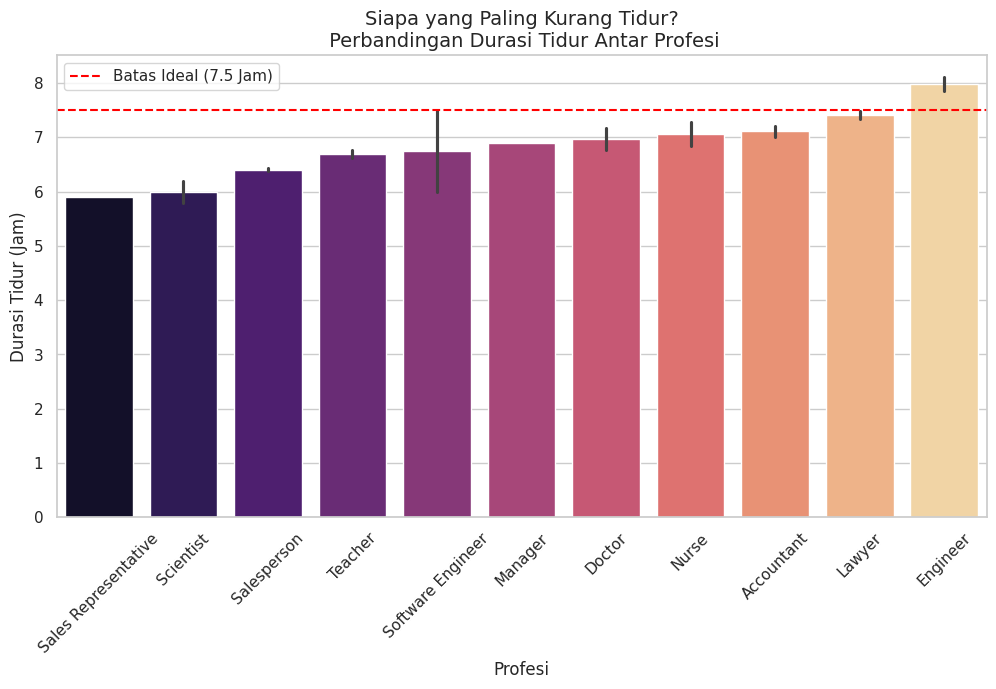

In [89]:
plt.figure(figsize=(12, 6))

order = df_viz.groupby('Occupation')['Sleep Duration'].mean().sort_values().index
sns.barplot(x='Occupation', y='Sleep Duration', data=df_viz, palette='magma', order=order)
plt.axhline(y=7.5, color='red', linestyle='--', label='Batas Ideal (7.5 Jam)')

plt.xticks(rotation=45)
plt.title('Siapa yang Paling Kurang Tidur?\n Perbandingan Durasi Tidur Antar Profesi', fontsize=14)
plt.xlabel('Profesi', fontsize=12)
plt.ylabel('Durasi Tidur (Jam)', fontsize=12)
plt.legend()
plt.show()

Garis merah adalah batas durasi tidur yang ideal yaitu selama 7.5 jam. Jika berada di bawah garis ideal, maka kelompok profesi tersebut secara kronis kekurangan waktu istirahat. Terlihat jelas profesi tertentu memiliki durasi tidur jauh dari durasi ideal.

### Korelasi Tingkat Stress dengan Kualitas Tidur

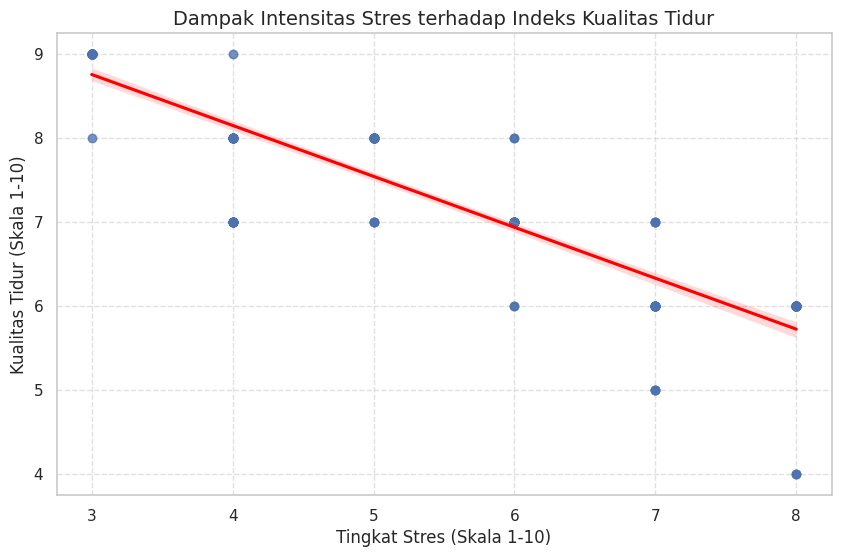

In [90]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Stress Level', y='Quality of Sleep', data=df_viz,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Dampak Intensitas Stres terhadap Indeks Kualitas Tidur', fontsize=14)
plt.xlabel('Tingkat Stres (Skala 1-10)', fontsize=12)
plt.ylabel('Kualitas Tidur (Skala 1-10)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Titik-titik ini menunjukkan data asli, dan garis merah adalah garis korelasi untuk mempermudah melihat tren pada data. Hasilnya membuktikan bahwa semakin stress seseorang, maka kualitas tidur juga semakin menurun.

### Distribusi Gangguan Tidur Berdasarkan BMI

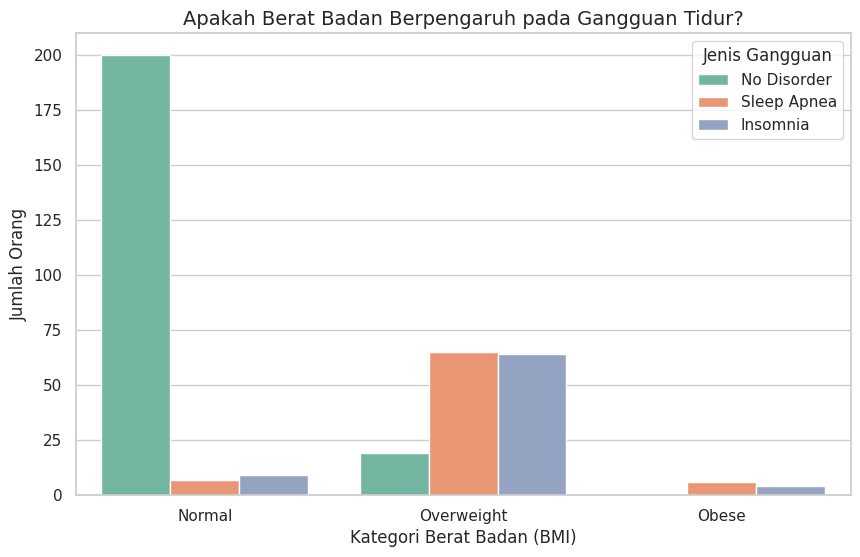

In [91]:
#Cleaning BMI Category
df_viz.columns = df_viz.columns.str.strip()

if 'BMI Category' in df_viz.columns:
    df_viz['BMI Category'] = df_viz['BMI Category'].replace('Normal Weight', 'Normal')
else:
    print("None")

#Visualisasi
plt.figure(figsize=(10, 6))
bmi_order = ['Normal', 'Overweight', 'Obese']
sns.countplot(x='BMI Category', hue='Sleep Disorder', data=df_viz, palette='Set2', order=bmi_order)

plt.title('Apakah Berat Badan Berpengaruh pada Gangguan Tidur?', fontsize=14)
plt.xlabel('Kategori Berat Badan (BMI)', fontsize=12)
plt.ylabel('Jumlah Orang', fontsize=12)
plt.legend(title='Jenis Gangguan')
plt.show()

Grafik ini membandingkan individu dengan berat badan Normal vs Berlebih. Berdasarkan visualisasi data diatas, jumlah individu dengan berat badan normal lebih sedikit yang mengalami gangguan tidur. Sedangkan jumlah individu dengan berat badan berlebih lebih banyak yang mengalami gangguan tidur. Maka dari itu, berat badan merupakan salah satu faktor yang berpengaruh pada gangguan tidur

### Hubungan Aktivitas Fisik dan Parameter Fisiologis

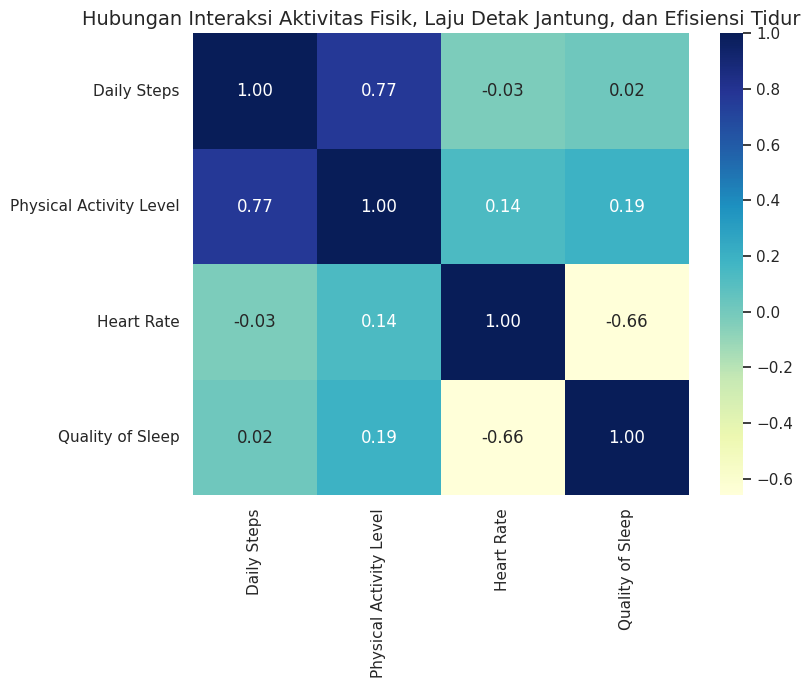

In [92]:
activity_focus = df_viz[['Daily Steps', 'Physical Activity Level', 'Heart Rate', 'Quality of Sleep']]

plt.figure(figsize=(8, 6))
sns.heatmap(activity_focus.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Hubungan Interaksi Aktivitas Fisik, Laju Detak Jantung, dan Efisiensi Tidur', fontsize=14)
plt.show()

Aktif bergerak tidak otomatis membuat tidur lebih berkualitas. Olahraga berat di siang hari pun bukan jaminan tidur nyenyak. Kualitas tidur lebih erat kaitannya dengan detak jantung. Detak jantung tinggi akibat stres atau kelelahan justru menurunkan kualitas tidur. Jadi, jumlah langkah kaki bukan faktor utama tetapi kondisi fisik dan mental lebih menentukan.

### Analisis Kualitas Tidur Sepanjang Siklus Usia

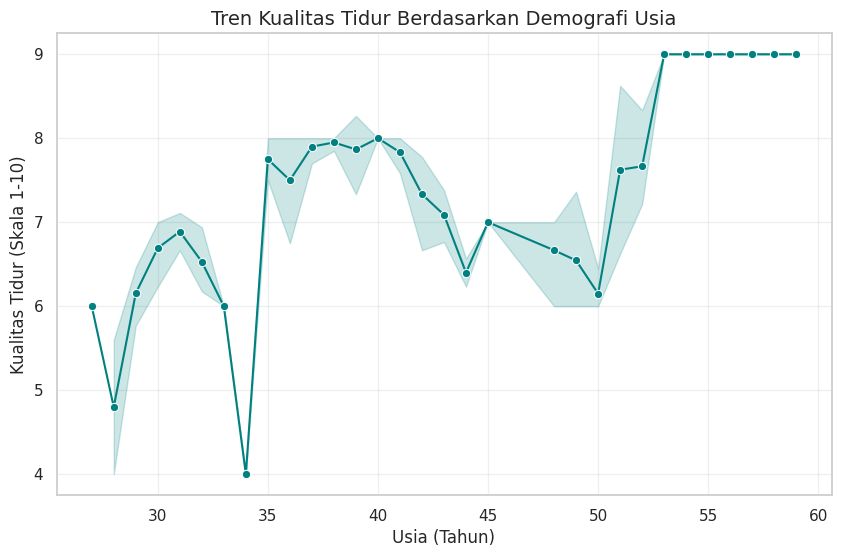

In [93]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age', y='Quality of Sleep', data=df_viz, marker='o', color='teal')

plt.title('Tren Kualitas Tidur Berdasarkan Demografi Usia', fontsize=14)
plt.xlabel('Usia (Tahun)', fontsize=12)
plt.ylabel('Kualitas Tidur (Skala 1-10)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Di usia produktif (antara 25 - 35), kualitas tidur paling tidak stabil. Ada masa di mana tidur sangat buruk dan ada juga masa pemulihan. Memasuki usia matang, orang cenderung memiliki rutinitas yang lebih teratur, sehingga kualitas tidur lebih terjaga. Memasuki usia lanjut (diatas 50 tahun) justru memiliki kualitas tidur yang paling sempurna dan stabil.

## Machine Learning

### KNN

In [94]:
X = df_model.drop('Sleep Disorder', axis=1)
y = df_model['Sleep Disorder']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Jumlah data latih: 299
Jumlah data uji: 75


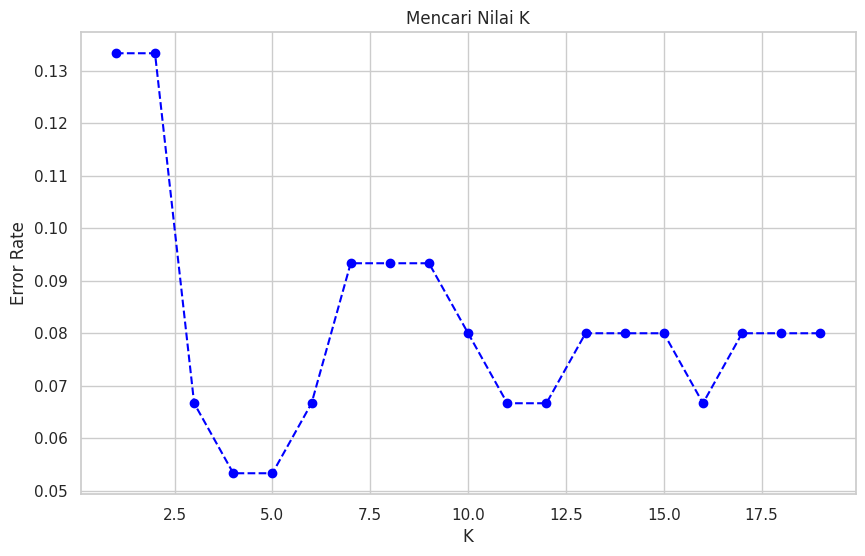

In [96]:
# Mencari K terbaik
error_rate = []
for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

# Visualisasi pencarian K
plt.figure(figsize=(10,6))
plt.plot(range(1,20), error_rate, color='blue', linestyle='dashed', marker='o')
plt.title('Mencari Nilai K')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [97]:
# Memilih K = 5
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

Akurasi Model: 94.67% 

              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       1.00      0.98      0.99        44
           2       0.93      0.88      0.90        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75



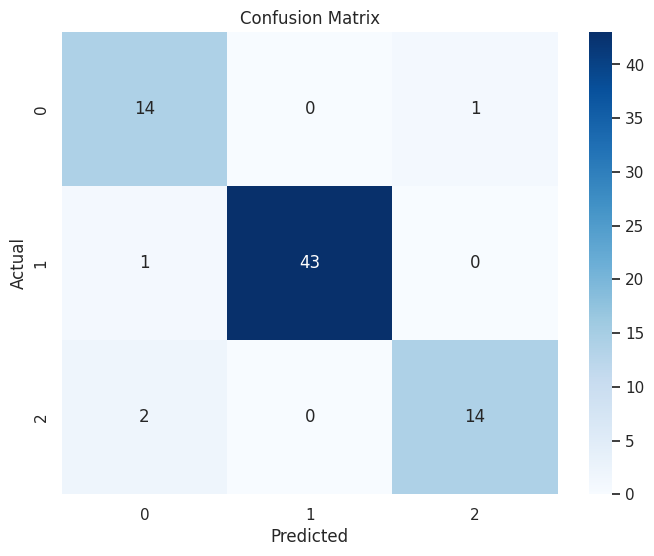

In [98]:
y_pred = model_knn.predict(X_test)

print(f"Akurasi Model: {accuracy_score(y_test, y_pred)*100:.2f}% \n")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Kesimpulan**

Algoritma berbasis instansi yang melakukan klasifikasi berdasarkan Euclidean Distance. Model ini memetakan titik data baru ke dalam ruang fitur dan menentukan kelas berdasarkan mayoritas label dari $k$ tetangga terdekatnya.

**Hasil:** Mencapai akurasi sebesar 94.67%. Tingginya akurasi KNN menunjukkan bahwa data dalam proyek ini memiliki kelompok (cluster) yang sangat jelas. Individu dengan gangguan tidur memiliki profil data yang sangat konsisten, sehingga tetangga yang mirip hampir selalu memiliki gangguan yang sama.

### Random Forest

In [99]:
# Inisialisasi Model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

Akurasi Model Random Forest: 92.00% 

              precision    recall  f1-score   support

           0       0.76      0.87      0.81        15
           1       1.00      0.98      0.99        44
           2       0.87      0.81      0.84        16

    accuracy                           0.92        75
   macro avg       0.88      0.89      0.88        75
weighted avg       0.92      0.92      0.92        75



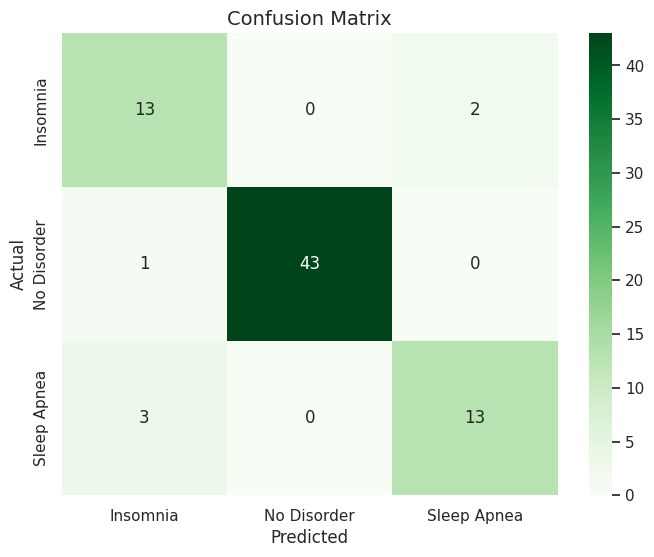

In [100]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Akurasi Model Random Forest: {accuracy_rf*100:.2f}% \n")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

Feature Importance

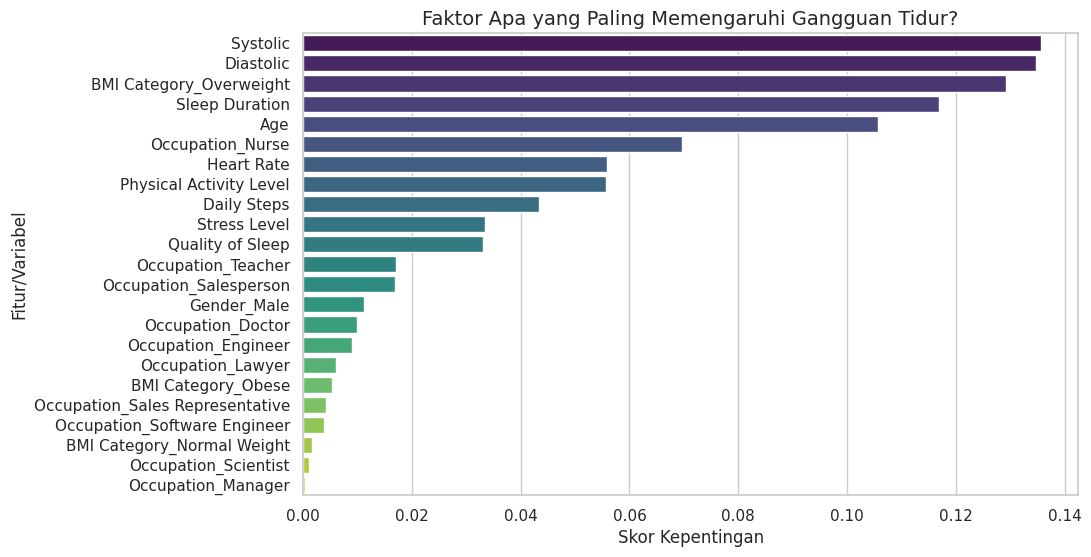

In [101]:
importances = model_rf.feature_importances_
feature_names = X.columns

forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=forest_importances.values, y=forest_importances.index, palette='viridis')
plt.title('Faktor Apa yang Paling Memengaruhi Gangguan Tidur?', fontsize=14)
plt.xlabel('Skor Kepentingan', fontsize=12)
plt.ylabel('Fitur/Variabel', fontsize=12)
plt.show()

Validasi

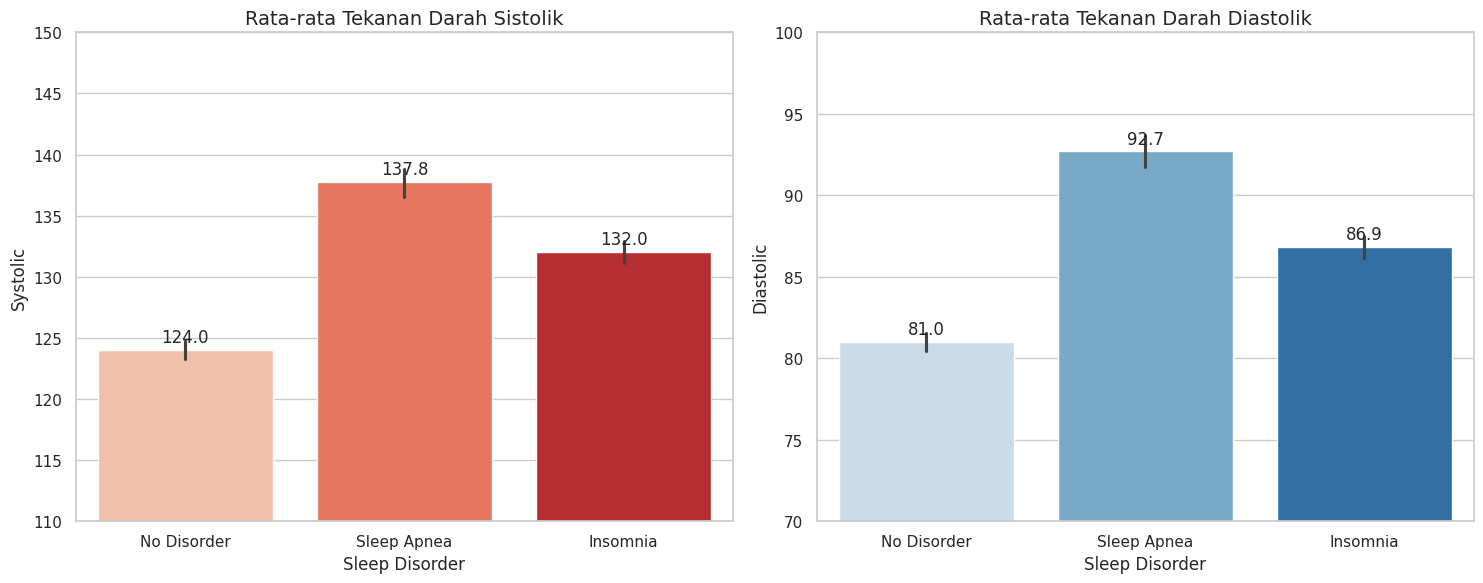

In [102]:
blood_pressure_summary = df_viz.groupby('Sleep Disorder')[['Systolic', 'Diastolic']].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot Systolic
sns.barplot(x='Sleep Disorder', y='Systolic', data=df_viz, palette='Reds', ax=ax[0])
ax[0].set_title('Rata-rata Tekanan Darah Sistolik', fontsize=14)
ax[0].set_ylim(110, 150)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Plot Diastolic
sns.barplot(x='Sleep Disorder', y='Diastolic', data=df_viz, palette='Blues', ax=ax[1])
ax[1].set_title('Rata-rata Tekanan Darah Diastolik', fontsize=14)
ax[1].set_ylim(70, 100)
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

**Kesimpulan**

Algoritma Ensemble Learning yang menggunakan metode Bagging dan Feature Randomness. RF membangun ratusan Decision Trees secara independen dan mengambil keputusan akhir melalui Majority Voting.

**Hasil:** Mencapai akurasi 92.00%. Melalui perhitungan Gini Impurity, RF memberikan keunggulan berupa Feature Importance, yang mengungkap bahwa variabel fisiologis (Systolic & Diastolic) memiliki Information Gain tertinggi sebagai prediktor gangguan tidur. Hal ini membuktikan bahwa gangguan tidur adalah masalah sistemik tubuh yang tercermin langsung pada sistem kardiovaskular.

## Kesimpulan

Proyek ini membuktikan bahwa parameter klinis (Tekanan Darah & Detak Jantung) memiliki bobot statistik yang lebih signifikan dalam memprediksi patologi tidur dibandingkan variabel gaya hidup subjektif. Kesederhanaan KNN terbukti lebih efisien untuk karakteristik data ini dibandingkan kompleksitas Random Forest.

Manfaat dari proyek ini menghasilkan sistem pendukung keputusan (Decision Support System) yang mampu melakukan deteksi dini gangguan tidur secara objektif, yang mungkin dapat diimplementasikan pada perangkat health wearables.